<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week7_Day1_Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 99.2 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """Convertit en minuscule, tokenize, retire la ponctuation, les mots vides et lemmatise."""
    # Mettre en minuscules
    text = text.lower()

    # Tokenisation (division du texte en mots)
    tokens = nltk.word_tokenize(text)

    # Suppression de la ponctuation
    tokens = [t for t in tokens if t not in string.punctuation]

    # Filtrage des mots vides (stopwords)
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatisation des tokens restants
    lemmatized = [lemmatizer.lemmatize(t) for t in tokens]

    # Rejoint les mots en une seule chaîne de caractères nettoyée
    return " ".join(lemmatized)

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [ ]:
import nltk
# Téléchargement explicite de la ressource manquante pour la tokenisation
nltk.download('punkt_tab')

# Application de la fonction preprocess_text à chaque critique dans raw_reviews
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Vérification que cleaned_reviews n'est plus None
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

# Affichage des versions brutes et nettoyées côte à côte
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [ ]:
import spacy

# Chargement du modèle si nlp n'est pas déjà défini globalement
try:
    nlp
except NameError:
    nlp = spacy.load("en_core_web_sm")

def perform_ner(text: str):
    """Retourne des paires (entité, label) trouvées par spaCy."""
    # Analyse du texte avec le pipeline spaCy nlp
    doc = nlp(text)

    # Extraction du texte de l'entité et de son étiquette (label_)
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return entities

# Test rapide sur la première critique
print(f"Entités trouvées : {perform_ner(raw_reviews[0])}")

Entités trouvées : [('McDonald', 'ORG')]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize

# Téléchargement de la ressource nécessaire pour le POS tagging
nltk.download('averaged_perceptron_tagger_eng')

def perform_pos_tagging(text: str):
    """Retourne les étiquettes POS pour un texte donné."""
    # Tokenisation du texte
    tokens = word_tokenize(text)
    # Application du POS tagging de NLTK
    pos_tags = pos_tag(tokens)
    return pos_tags

# Test sur la première critique
print(f"POS tags (Original) : {perform_pos_tagging(raw_reviews[0])}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


POS tags (Original) : [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_raw = raw_reviews[:2]
sample_cleaned = cleaned_reviews[:2]

print("--- NER Comparison ---")
for r, c in zip(sample_raw, sample_cleaned):
    print(f"Raw: {perform_ner(r)}")
    print(f"Cleaned: {perform_ner(c)}\n")

print("--- POS Comparison ---")
for r, c in zip(sample_raw, sample_cleaned):
    print(f"Raw: {perform_pos_tagging(r)[:5]}...") # Affichage partiel pour la clarté
    print(f"Cleaned: {perform_pos_tagging(c)[:5]}...\n")

--- NER Comparison ---
Raw: [('McDonald', 'ORG')]
Cleaned: [("mcdonald 's food ok service", 'ORG')]

Raw: [('Japanese', 'NORP')]
Cleaned: [('japanese', 'NORP')]

--- POS Comparison ---
Raw: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN')]...
Cleaned: [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN')]...

Raw: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT')]...
Cleaned: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]...



## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [ ]:
from gensim.models import Word2Vec

# Tokenisation des critiques nettoyées (division par espace)
tokenized_reviews = [review.split() for review in cleaned_reviews]

# Entraînement du modèle Word2Vec
# min_count=1 car notre jeu de données est très petit
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=1)

print("Modèle Word2Vec entraîné avec succès.")
w2v_model

Modèle Word2Vec entraîné avec succès.


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [ ]:
# Taille du vecteur de caractéristiques
vector_size = w2v_model.vector_size
# Nombre de mots uniques dans le vocabulaire
vocab_size = len(w2v_model.wv)

print(f"Taille du vecteur : {vector_size}")
print(f"Taille du vocabulaire : {vocab_size}")

# Interprétation : Chaque mot est représenté par un vecteur de 100 dimensions dans un espace sémantique.

Taille du vecteur : 100
Taille du vocabulaire : 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

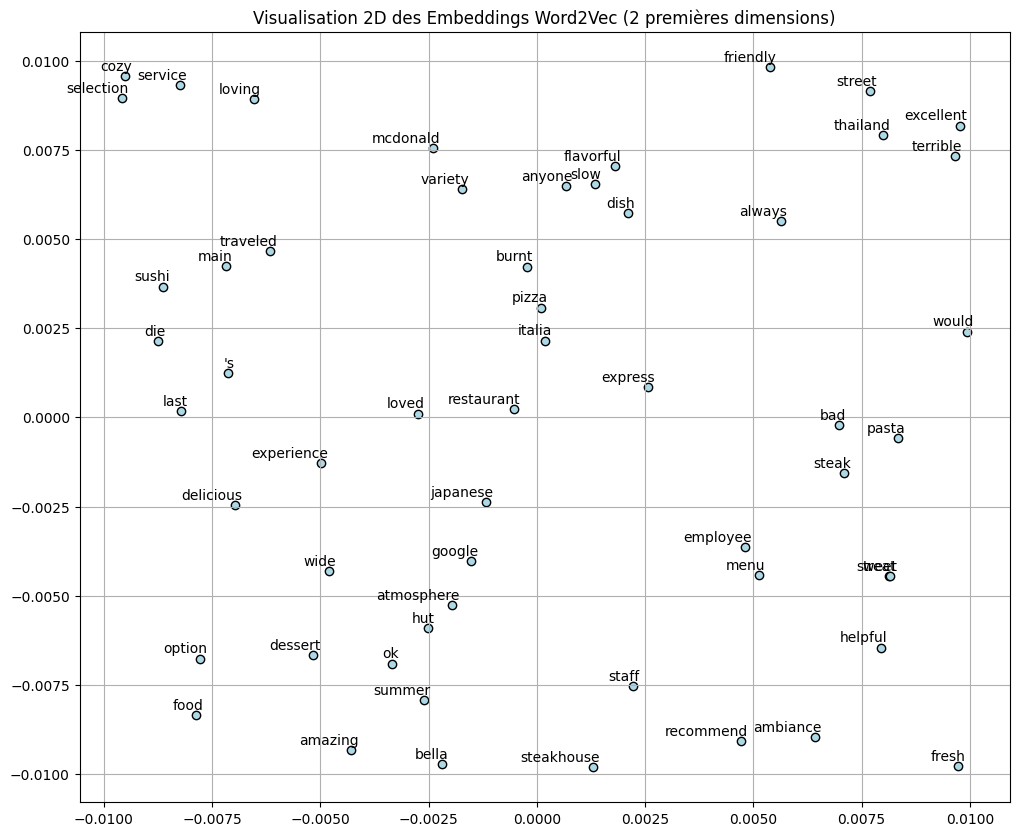

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model, words=None):
    """Affiche les embeddings des mots en 2D en utilisant les deux premières dimensions."""
    if words is None:
        words = list(model.wv.index_to_key)

    # Extraction des vecteurs
    vectors = np.array([model.wv[word] for word in words])

    # On utilise les deux premières dimensions pour la visualisation simple
    x = vectors[:, 0]
    y = vectors[:, 1]

    plt.figure(figsize=(12, 10))
    plt.scatter(x, y, edgecolors='k', c='lightblue')

    # Ajout des étiquettes pour chaque mot
    for i, word in enumerate(words):
        plt.annotate(word, xy=(x[i], y[i]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    plt.title("Visualisation 2D des Embeddings Word2Vec (2 premières dimensions)")
    plt.grid(True)
    plt.show()

# Appel de la fonction de visualisation
plot_word_embeddings(w2v_model)

### 2.4 Exploration avancée : PCA et Paramétrage

Pour une meilleure visualisation, nous utilisons **PCA (Principal Component Analysis)** pour projeter les dimensions sur un plan 2D tout en conservant le maximum de variance.

Erreur : cleaned_reviews n'est pas défini. Assurez-vous d'exécuter la section 1.2.


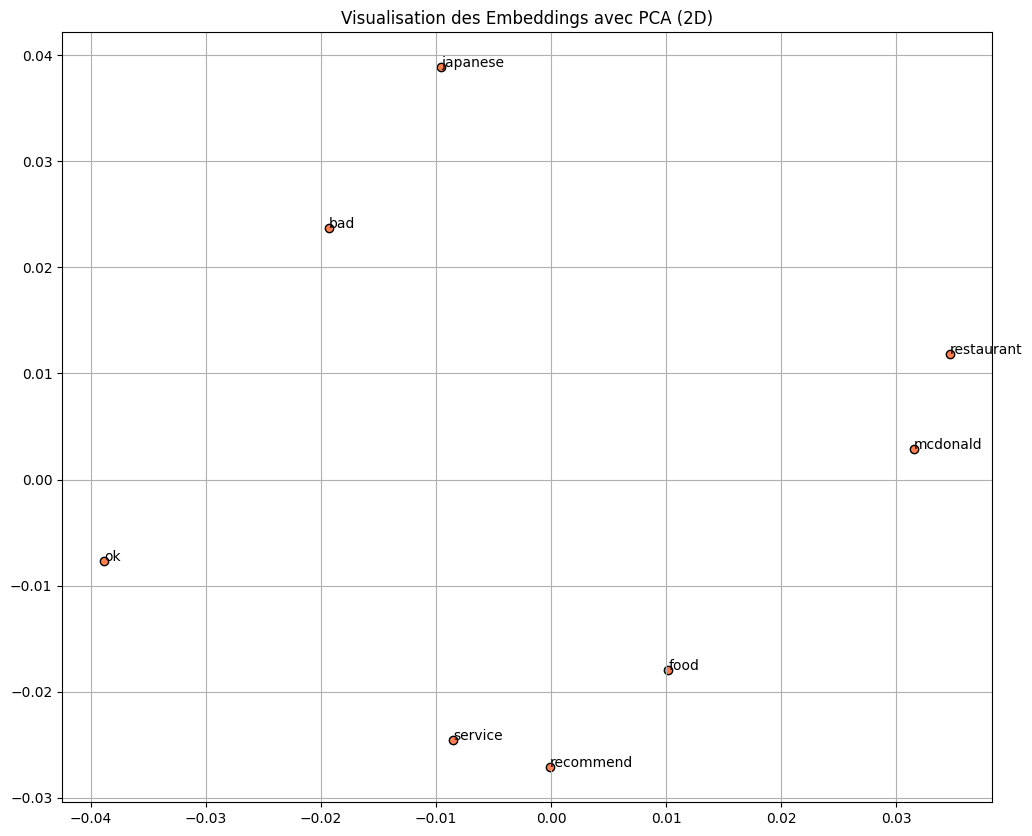

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
try:
    from gensim.models import Word2Vec
except ImportError:
    print("Gensim n'est pas installé. Installation en cours...")
    !pip install gensim
    from gensim.models import Word2Vec

def plot_embeddings_pca(model):
    words = list(model.wv.index_to_key)
    vectors = np.array([model.wv[word] for word in words])

    # Réduction de dimension avec PCA
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(result[:, 0], result[:, 1], edgecolors='k', c='coral')

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), size=10)

    plt.title("Visualisation des Embeddings avec PCA (2D)")
    plt.grid(True)
    plt.show()

# Vérification et récupération de cleaned_reviews si nécessaire
try:
    tokenized_reviews = [review.split() for review in cleaned_reviews]
except NameError:
    print("Erreur : cleaned_reviews n'est pas défini. Assurez-vous d'exécuter la section 1.2.")
    # Solution de secours pour le test :
    tokenized_reviews = ["mcdonald food ok service bad".split(), "recommend japanese restaurant".split()]

w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=1)
plot_embeddings_pca(w2v_model)

### Ajustement des Hyperparamètres
Vous pouvez modifier `vector_size` (taille de l'espace), `window` (contexte) ou `sg` (0 pour CBOW, 1 pour Skip-gram) pour voir comment les regroupements sémantiques évoluent.

Nouveau modèle (CBOW) entraîné.


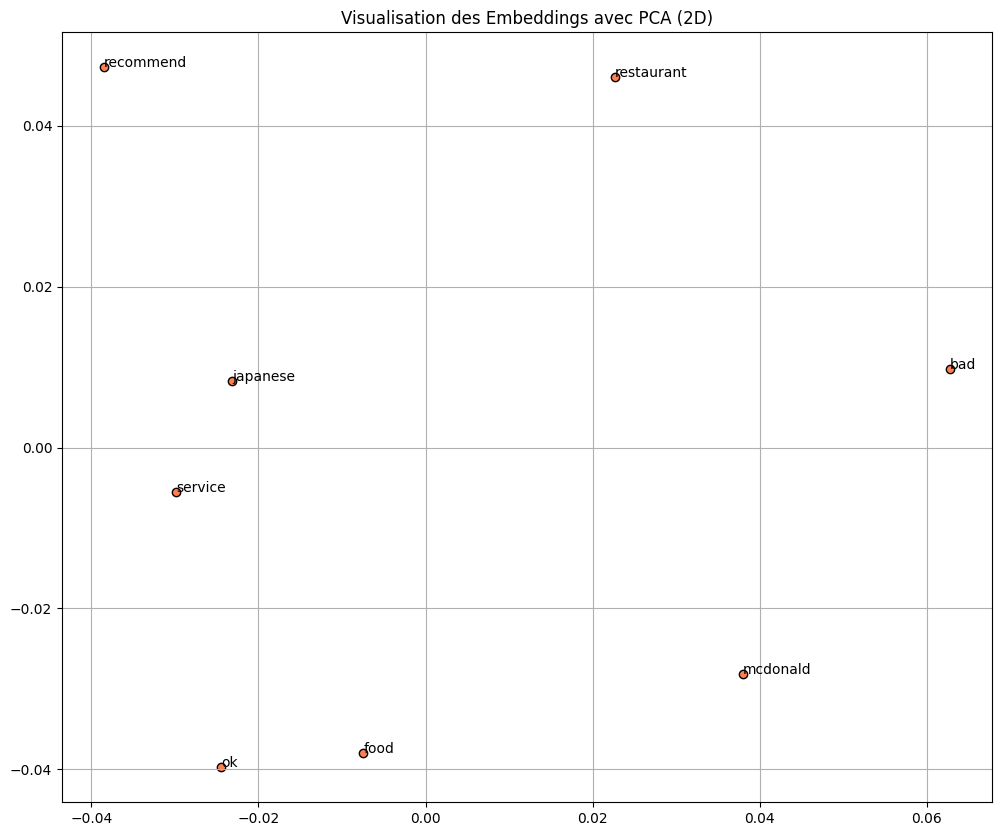

In [ ]:
from gensim.models import Word2Vec

# Exemple : Modèle CBOW avec une fenêtre plus petite
model_cbow = Word2Vec(sentences=tokenized_reviews, vector_size=50, window=2, min_count=1, sg=0)
print("Nouveau modèle (CBOW) entraîné.")
plot_embeddings_pca(model_cbow)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.